# Load QICK

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from qick import *

from qick.asm_v2 import QickSpan, QickSweep1D

from QickworkspaceV2 import BaseExperiment

soc, soccfg = BaseExperiment.connect_pyro4(
    ns_host="192.168.10.82",
    ns_port=8888,
    proxy_name="myqick",
    data_path=r"D:\Labber_Data\Jay\purcell_tmon\Eccosorb_Rshield",
)

print(soccfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_57cd43aadc774bb1a3d4dbeb8b31f75e@192.168.10.82:40803
[BaseExperiment] Session activated: QICK@192.168.10.82:8888/myqick, data_path='D:\\Labber_Data\\Jay\\purcell_tmon\\Eccosorb_Rshield'
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DD

# Qubit Setting

In [5]:
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.config.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

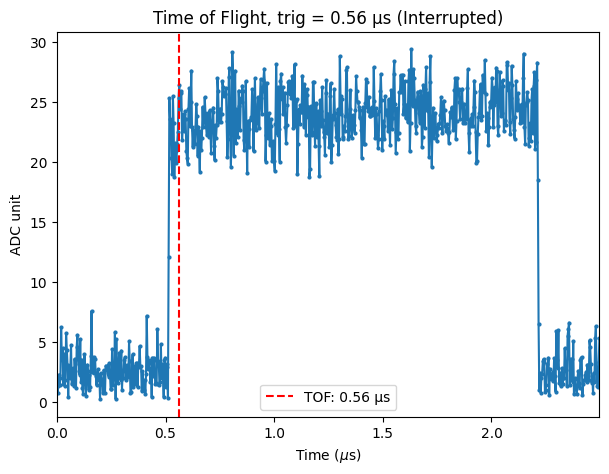

ExperimentData(type='s001_tof', id='bf564e06', quality=no_information, status=interrupted)

In [7]:
from QickworkspaceV2.experiments.setup import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_freq_ge": 6500,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": False,
        "relax_delay": 1,
    }
)

tof = TOF(run_cfg)
tof.run(1000)
# tof.saveLabber(qubit)

# Instrument Setting

Use `BaseInstrumentManager` to connect Yoko flux sources and RF sources. Fill in your lab addresses before running.

In [3]:
from QickworkspaceV2.instruments import BaseInstrumentManager

inst = BaseInstrumentManager()

# Fill these before running. SGS100A/MG3692 accept either plain IP or full VISA string.
Q1_FLUX_ADDR = "USB0::0x0B21::0x0039::91S522309::INSTR"
Q2_FLUX_ADDR = ""  # Optional second Yoko; leave empty to skip
MG3692_ADDR = "192.168.10.182"

Q1_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}
Q2_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}

q1_flux = inst.add_yoko(
    "q1_flux",
    Q1_FLUX_ADDR,
    limits=Q1_FLUX_LIMITS,
    current_ramp_step=1e-8,
    voltage_ramp_step=1e-5,
    ramp_interval=0.01,
)

q2_flux = None
if Q2_FLUX_ADDR:
    q2_flux = inst.add_yoko(
        "q2_flux",
        Q2_FLUX_ADDR,
        limits=Q2_FLUX_LIMITS,
        current_ramp_step=1e-8,
        voltage_ramp_step=1e-5,
        ramp_interval=0.01,
    )

lo = inst.add_mg3692("pump", MG3692_ADDR)

inst.status

Connected to: YOKOGAWA,GS210,91S522309,2.02
Connected to: ANRITSU,MG3692C,192403,3.62


yoko: q1_flux address: USB0::0x0B21::0x0039::91S522309::INSTR | output: off | value: current=0.0 A, ramp=I_step=1e-08, V_step=1e-05, interval=0.01
mg3692: pump address: TCPIP::192.168.10.182::INSTR | output: False | value: power=-20.0 dBm, frequency=6000000000.0 Hz

In [7]:
inst.set_value("q1_flux", 0.0, mode="current")

Yoko current -9.98 uA -> 0 A:   0%|          | 0/999 [00:00<?, ?step/s]

## Instrument Quick Checks

Read-only checks plus optional write examples. The write examples are commented out intentionally.

In [ ]:
inst.help()
# inst.limits()
# inst.value("q1_flux")
# inst.ramp("q1_flux")

# Optional Yoko set test. tqdm will show target/current value and remaining time.
# inst.set_value("q1_flux", 0.0, mode="current")

# Optional MG3692 LO setup. Confirm safe frequency/power before uncommenting.
# inst.set(pump", "frequency", 6.0e9)
# inst.set_value("lo", -40)
# inst.off("pump")
# inst.status

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\QickworksaceV2_proj\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)
c:\Users\cluster\Desktop\QickworksaceV2_proj\QickworkspaceV2\analysis\resonator.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


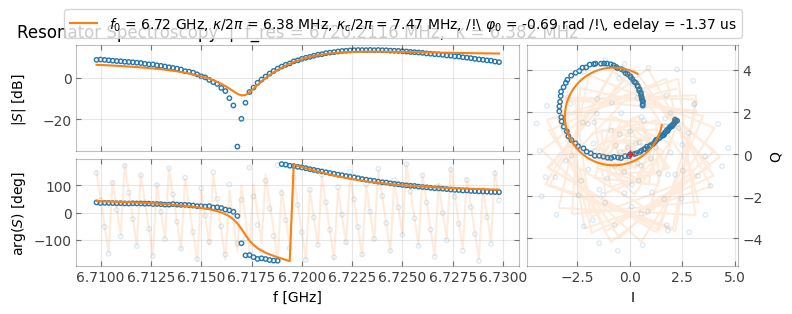

In [12]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]



STEPS = 101

config_all.update("res_gain_ge", 0.15, q_index=qubit)
config_all.update("res_simga", 0.01)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", result["f_res[MHz]"], q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## Resonator OneTone Flux

Sweep resonator frequency while stepping a Yoko current through `BaseInstrumentManager`. Yoko sweeps now use the manager-registered instrument name.

In [ ]:
from QickworkspaceV2.experiments.resonator import ResonatorSpecFlux

YOKO_NAME = "q1_flux"
YOKO_MODE = "current"

CENTER_FREQ = config_all.get_qubit(qubit)["res_freq_ge"]  # MHz
FREQ_SPAN = 100  # MHz
START_FREQ = CENTER_FREQ - FREQ_SPAN / 2
STOP_FREQ = CENTER_FREQ + FREQ_SPAN / 2
STEPS = 101

FLUX_START = -0.5e-3  # A
FLUX_STOP = 0.5e-3    # A
FLUX_STEPS = 11
yoko_values = np.linspace(FLUX_START, FLUX_STOP, FLUX_STEPS)

config_all.update("res.res_gain_ge", 0.4, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
        ("yoko_value", yoko_values),
    ]
)

onetone_flux = ResonatorSpecFlux(run_cfg)
result_flux = onetone_flux.run(
    py_avg=5,
    instrument_manager=inst,
    yoko_name=YOKO_NAME,
    yoko_value=yoko_values,
    yoko_mode=YOKO_MODE,
    show_final_plot=True,
)

# onetone_flux.saveLabber(qubit, config_all=config_all)

## OneTone PunchOut

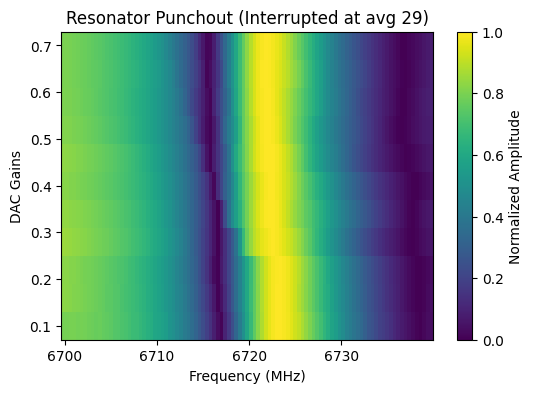

Experiment interrupted at 29 averages. Fit is based on partial data.


ExperimentData(type='s002b_res_ge_punchout', id='844281a8', quality=no_information, status=interrupted)

In [10]:
from QickworkspaceV2.experiments.resonator import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]

STEPS_freq = 101

START_gain = 0.1
STOP_gain = 0.7
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
# punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 18 averages. Fit is based on partial data.


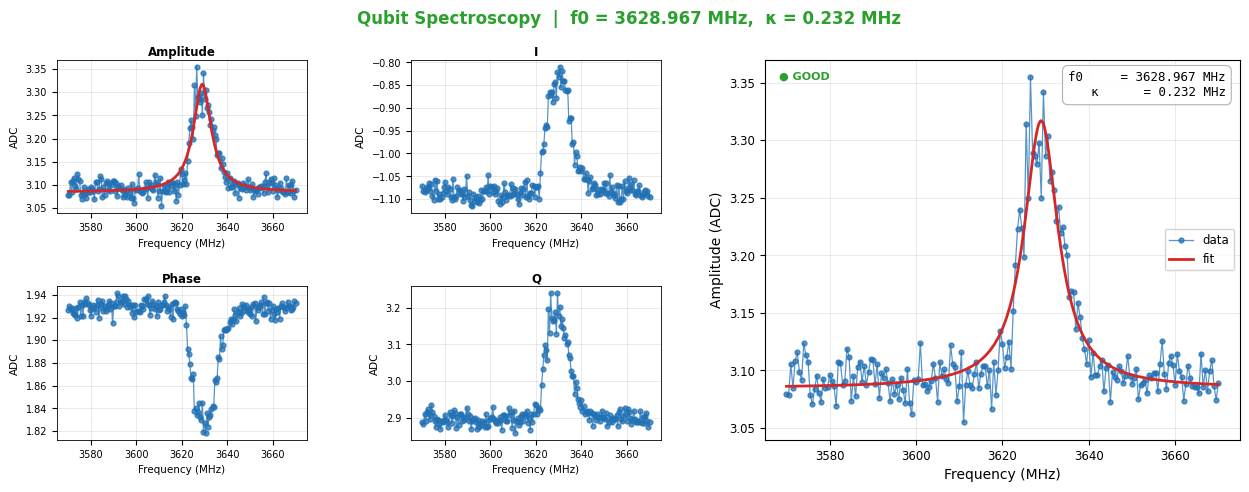

In [13]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpec

center = 3620
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", 3),
        ("relax_delay", 1),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = QubitSpec(run_cfg)
spectrum_ge.run(50)
f_ge = spectrum_ge.result["f0_MHz"]
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)
# spectrum_ge.saveLabber(qubit, config_all=config_all)

### Fast flux spectrum

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN = 1
STEPS_GAIN = 11

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)

## Time Rabi ge

Experiment interrupted at 8 averages. Fit is based on partial data.


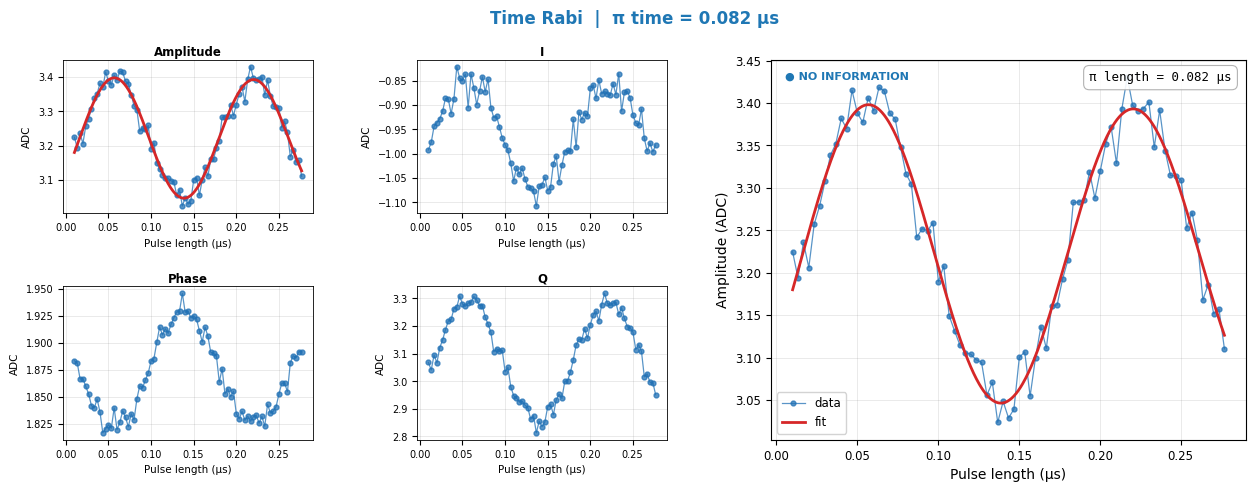

ExperimentData(type='s004_time_rabi_ge', id='c2474309', quality=no_information, status=interrupted)

In [14]:
from QickworkspaceV2.experiments.qubit_ge import TimeRabi

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 5 averages. Fit is based on partial data.


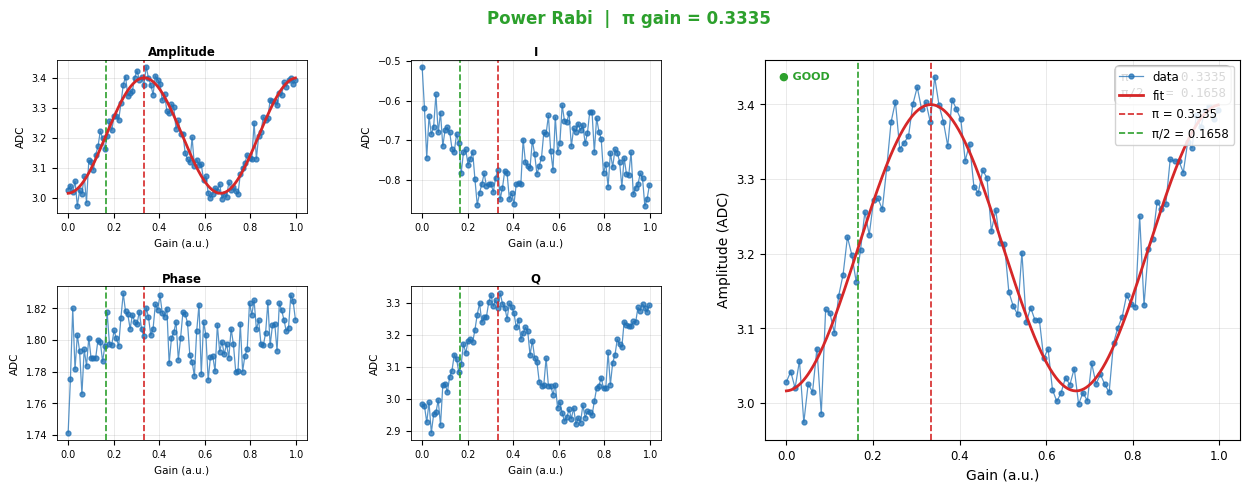

In [23]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(run_cfg)
prabi.run(50)
pi_gain, pi2_gain = prabi.result["pi_gain"], prabi.result["pi2_gain"]
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)
# prabi.saveLabber(qubit, config_all=config_all)

## Amplified Amplitude Error (AAE)


[PowerRabi] Optimal pi gain = 0.290017


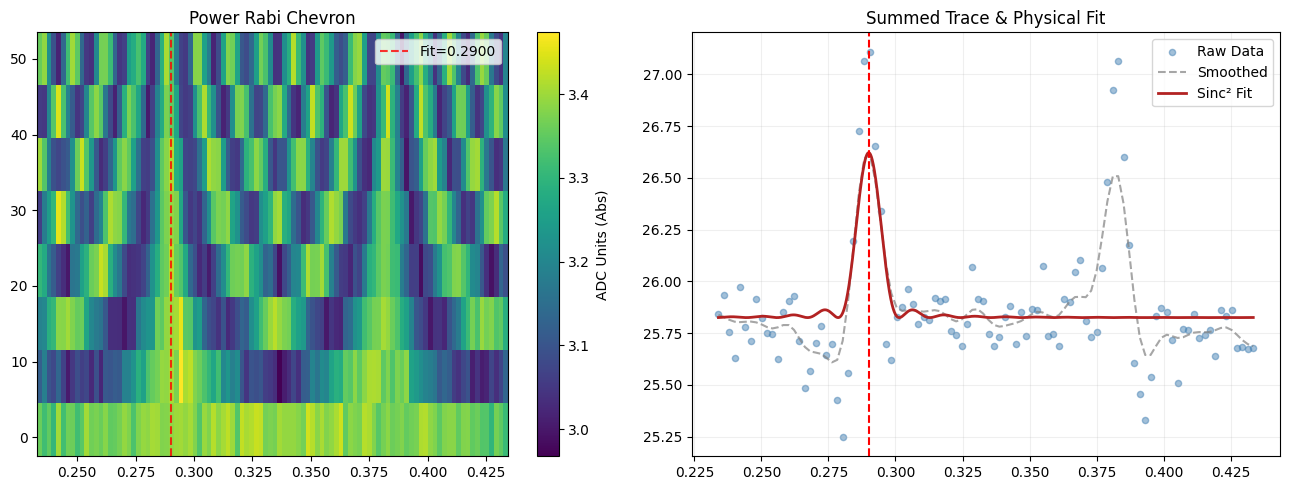

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg["pi_gain_ge"]
delta = run_cfg["pi_gain_ge"] - run_cfg["pi2_gain_ge"]
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus - delta, focus + delta)),
        # ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        ('reps', 5)
    ]
)

aae = PowerRabiChevron(run_cfg)
result = aae.run(100)
# config_all.update("pi_gain_ge", result, q_index=qubit)
# config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
# aae.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 4 averages. Fit is based on partial data.


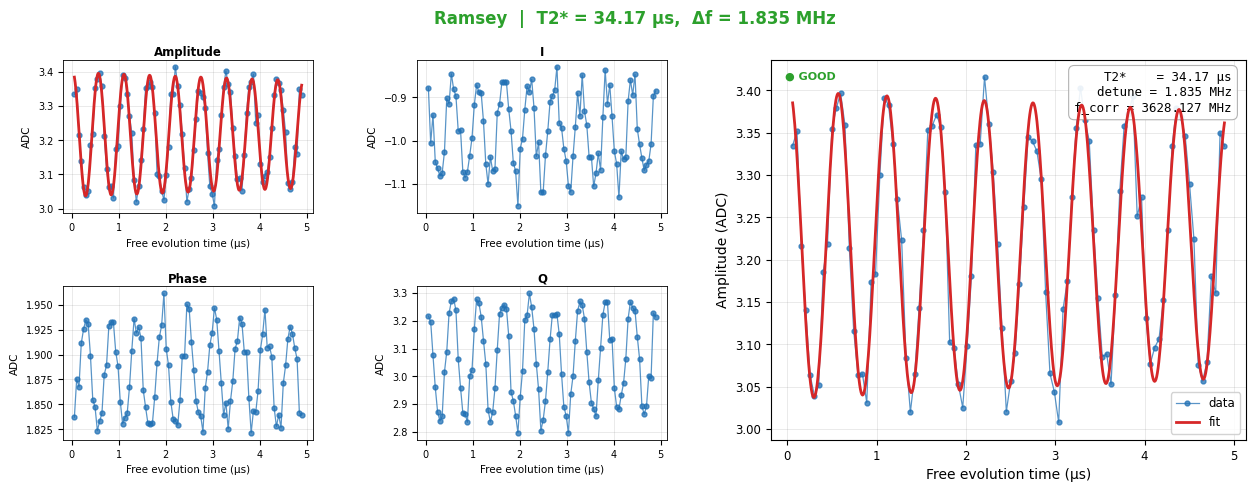

ExperimentData(type='s006_Ramsey_ge', id='66127b4b', quality=good, status=interrupted)

In [16]:
from QickworkspaceV2.experiments.coherence import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 1),
        # ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(run_cfg)
t2r.run(20)
# t2r.saveLabber(qubit, config_all=config_all)

In [17]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.83511MHz


## Spin Echo

Experiment interrupted at 14 averages. Fit is based on partial data.


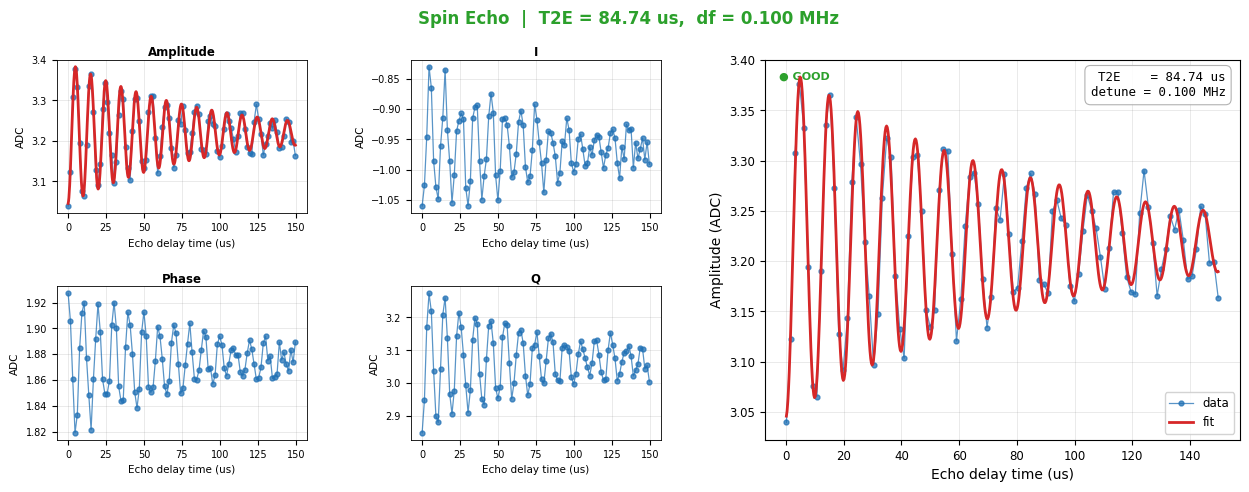

ExperimentData(type='s007_SpinEcho_ge', id='554e5975', quality=good, status=interrupted)

In [26]:
from QickworkspaceV2.experiments.coherence import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 150  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.1),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(run_cfg)
t2e.run(100)
# t2e.saveLabber(qubit, config_all=config_all)

## T1 ge

Experiment interrupted at 17 averages. Fit is based on partial data.


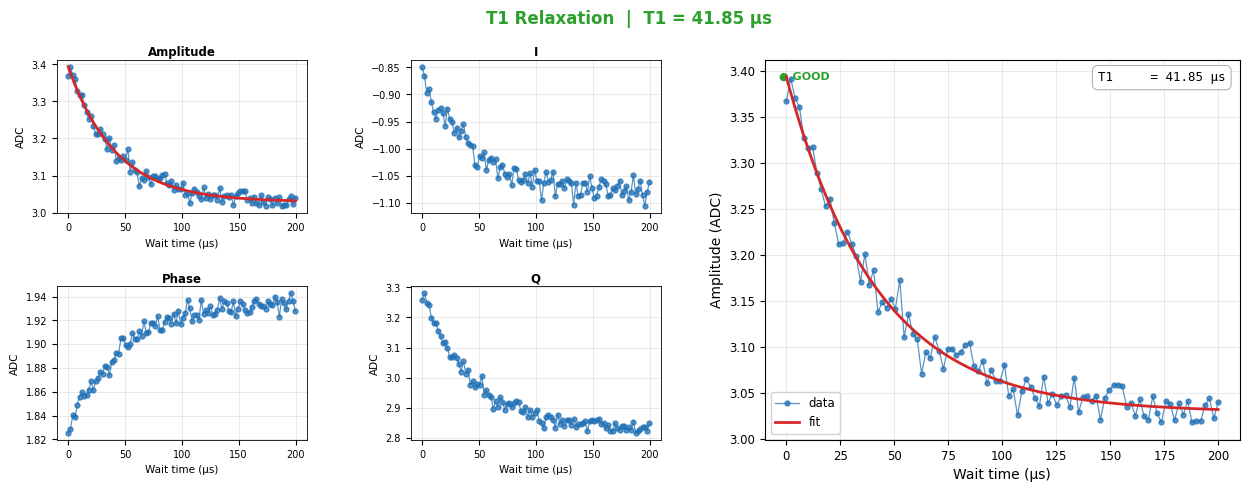

ExperimentData(type='s008_T1_ge', id='733a49f9', quality=good, status=interrupted)

In [27]:
from QickworkspaceV2.experiments.coherence import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 200  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ("pulse_type", "drag"),
    ]
)

t1 = T1(run_cfg)
t1.run(50)
# t1.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

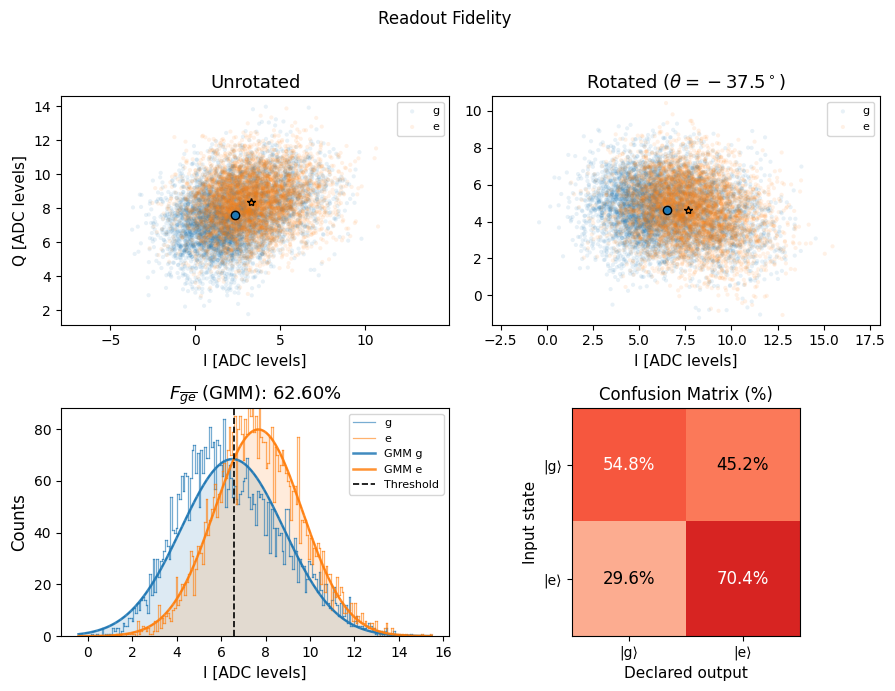

Rotation angle : -37.50 deg
GMM Fidelity   : 62.600%
  |g⟩  components=1  primary_mean=6.506  primary_std=2.315  secondary_weight=0.000
  |e⟩  components=1  primary_mean=7.670  primary_std=1.984  secondary_weight=0.000
Thresholds     : ['6.560']
Confusion Matrix (%):
 [[54.8 45.2]
 [29.6 70.4]]


In [29]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

# run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update("res_phase", ssh_result[2], q_index=qubit)
# ssh.saveLabber(qubit)

### ssh opt

Length loop:   0%|          | 0/11 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/7 [00:00<?, ?it/s]

Analyze [GMM fidelity (ge)]:   0%|          | 0/11 [00:00<?, ?it/s]


67/77 grid points pass physical constraints.

--- Grid best (feasible) ---
  fid=0.7640  length=9.399999999999999  gain=0.2  freq=6719.544933


  0%|          | 0/5000 [00:00<?, ?it/s]

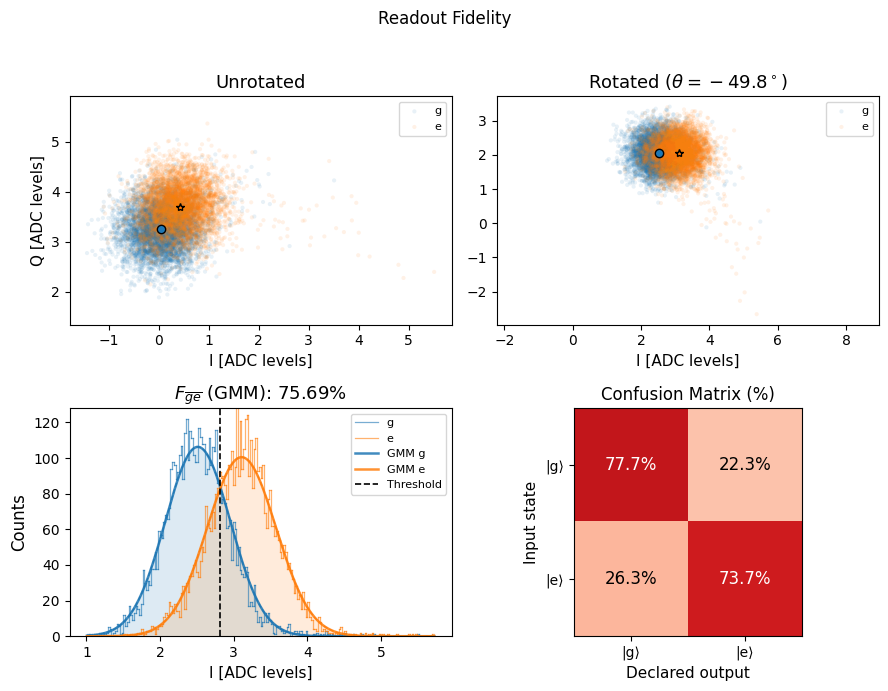

Rotation angle : -49.80 deg
GMM Fidelity   : 75.690%
  |g⟩  components=1  primary_mean=2.512  primary_std=0.442  secondary_weight=0.000
  |e⟩  components=1  primary_mean=3.107  primary_std=0.468  secondary_weight=0.000
Thresholds     : ['2.819']
Confusion Matrix (%):
 [[77.7 22.3]
 [26.3 73.7]]


In [40]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt
from QickworkspaceV2.experiments.setup import SingleShot_gef
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 2, run_cfg["res_freq_ge"] + 2, 4)
gain_axis = np.linspace(0.1, 0.3, 7)
length_axis = np.linspace(4, 10, 11)
sweep_para = {"freq": run_cfg["res_freq_ge"], "gain": gain_axis, "length": length_axis}

SHOT = 2000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze(pareto=True)

config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update("res_phase", ssh_result[2], q_index=qubit)


=== Top 5 points (feasible first, then by fidelity) ===
         L         G         F     fid    soft     snr    leak   therm   ok?
       9.4       0.2      6720  0.7640  0.6664   0.905  0.000  0.000   yes
        10       0.2      6720  0.7612  0.6586   0.838  0.000  0.000   yes
       8.8       0.2      6720  0.7610  0.6578   0.835  0.000  0.000   yes
       8.2       0.2      6720  0.7572  0.6570   0.836  0.000  0.000   yes
       9.4    0.2333      6720  0.7568  0.6433   0.694  0.000  0.000   yes

=== Diagnostics for best point ===
  [ok] Leakage OK (0.000)
  [ok] Thermal population OK (0.000)
  [ok] Hard and soft fidelities agree (delta = -0.0976).

=== Full hist for best point: L=9.4, G=0.2, F=6720  (fid=0.7640, soft=0.6664) ===


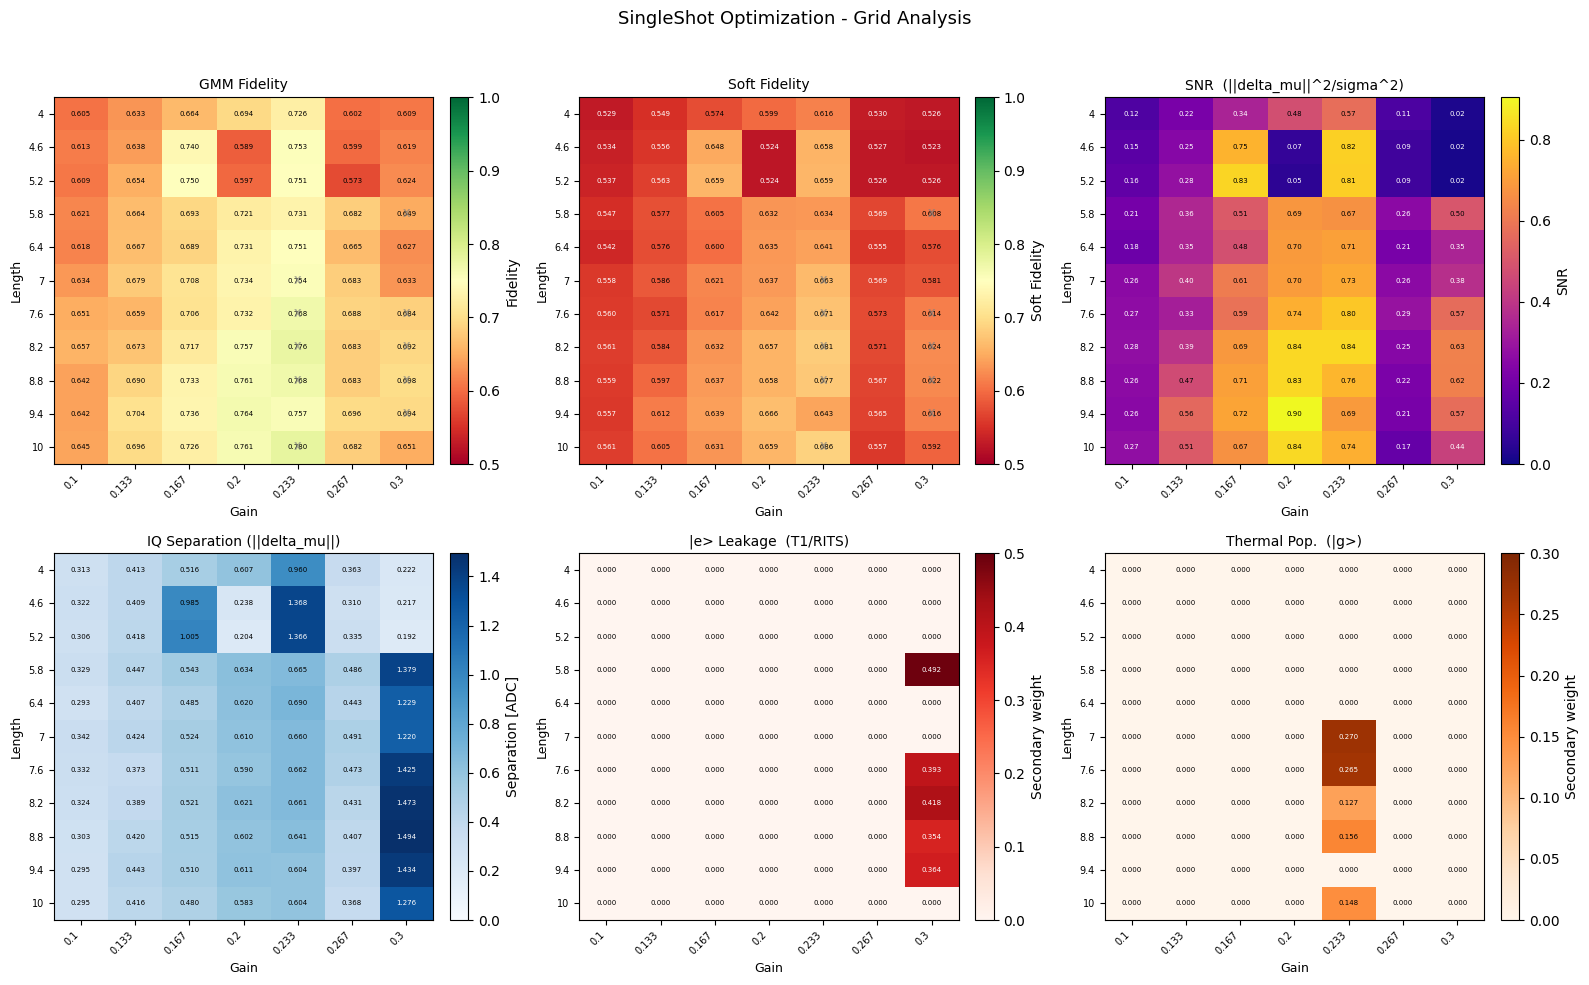

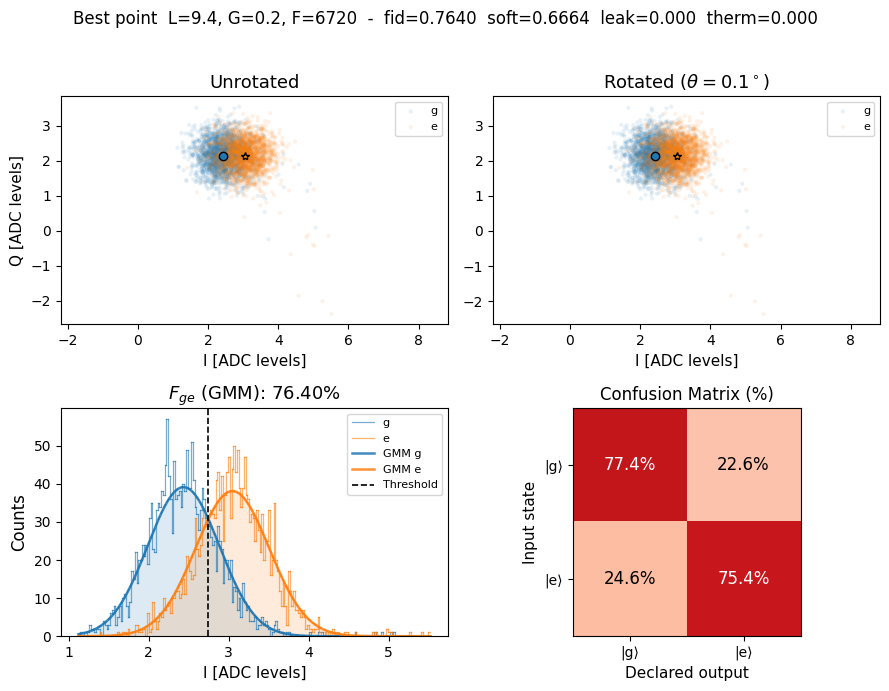

Rotation angle : 0.08 deg
GMM Fidelity   : 76.400%
  |g⟩  components=1  primary_mean=2.434  primary_std=0.448  secondary_weight=0.000
  |e⟩  components=1  primary_mean=3.046  primary_std=0.460  secondary_weight=0.000
Thresholds     : ['2.743']
Confusion Matrix (%):
 [[77.4 22.6]
 [24.6 75.4]]


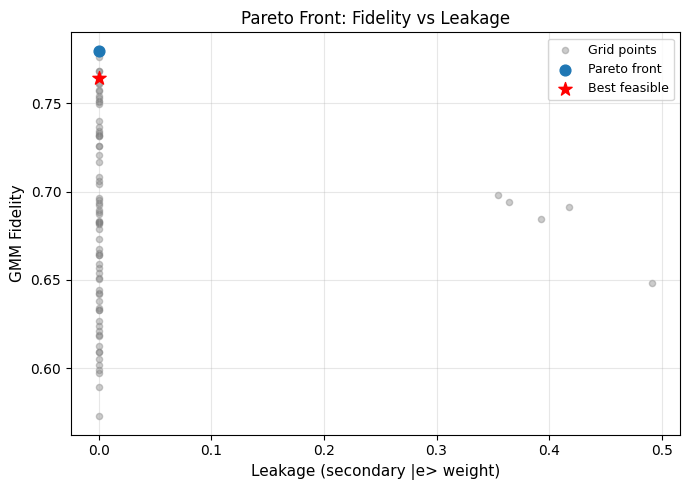


Plotting top 9 fidelity points (feasible only)...


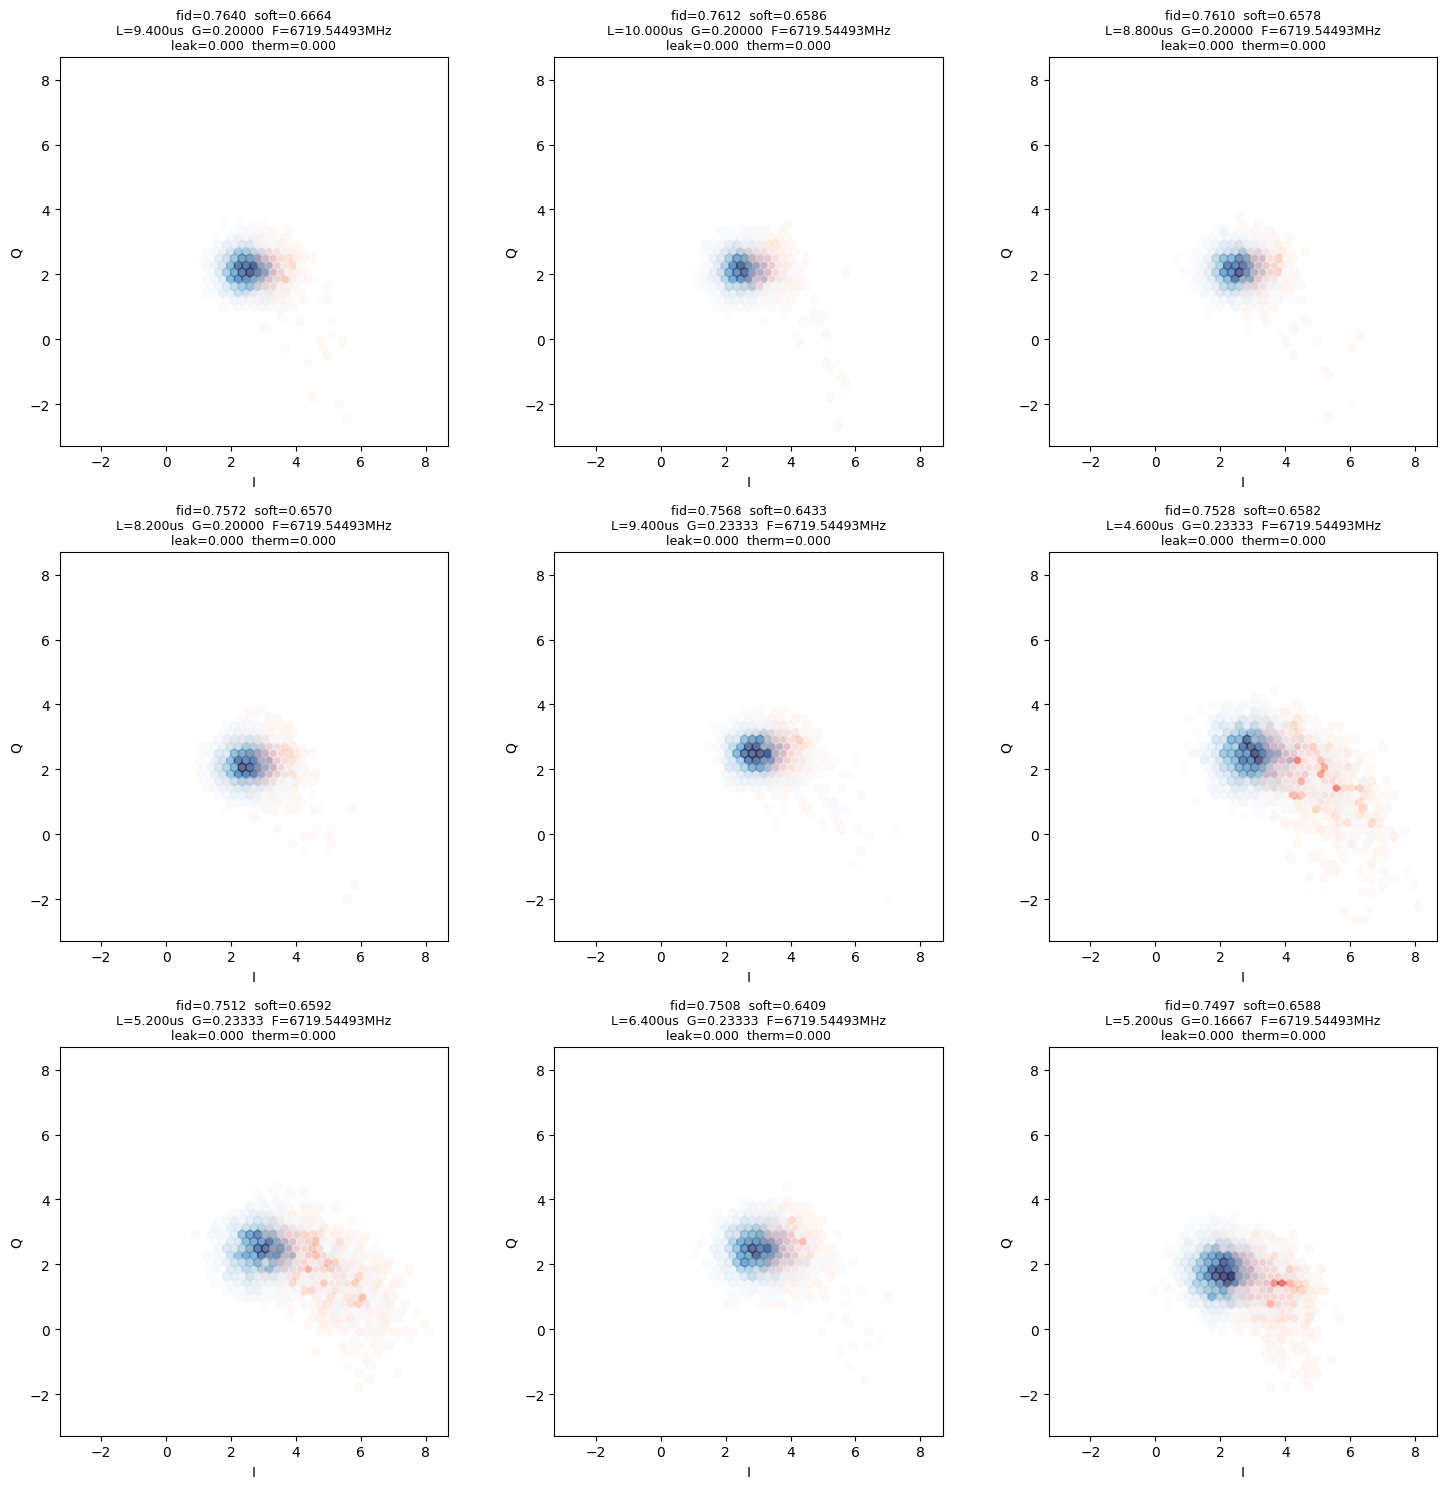

In [41]:
ssh_opt.plot_grid_analysis()
ssh_opt.plot_pareto()
ssh_opt.plot_top_fidelity_histograms(top_n=9)

# EF State

## Resonator OneTone ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
    ]
)

onetone_ef = ResonatorSpec_ef(run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", fres["f_res[MHz]"], q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 9 averages. Fit is based on partial data.


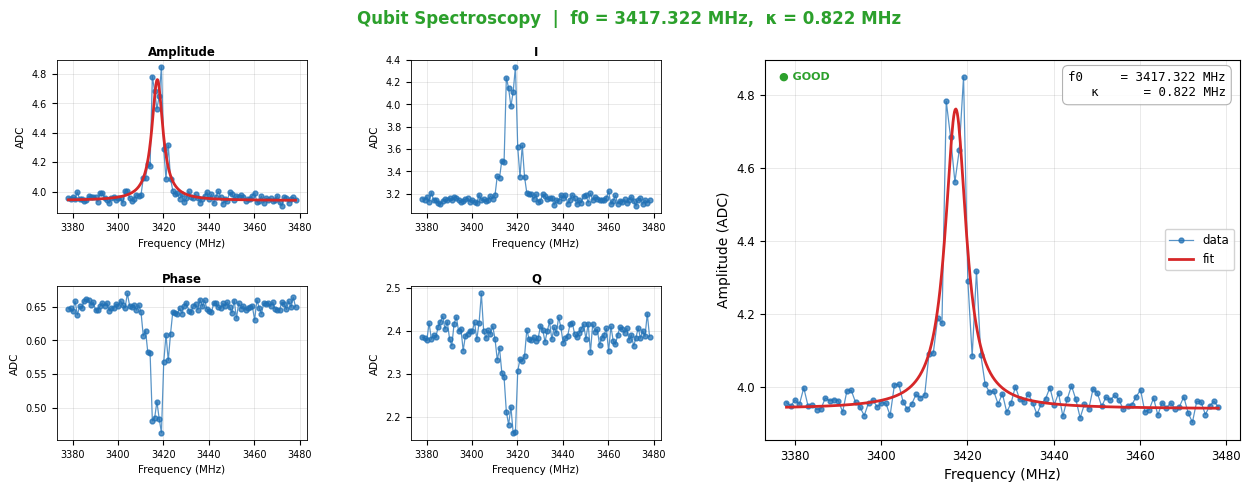

In [32]:
from QickworkspaceV2.experiments.qubit_ef import QubitSpecEf

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101

config_all.update("qb_ch_ef", 2, q_index=qubit)
config_all.update("nqz_qb_ef", 1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpecEf(run_cfg)
result_ef = spectrum_ef.run(10)
f_ef = result_ef.scalar_result
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb_mixer_ef", f_ef, q_index=qubit)
spectrum_ef.saveLabber(qubit, config_all=config_all)

## Power Rabi ef

Experiment interrupted at 12 averages. Fit is based on partial data.


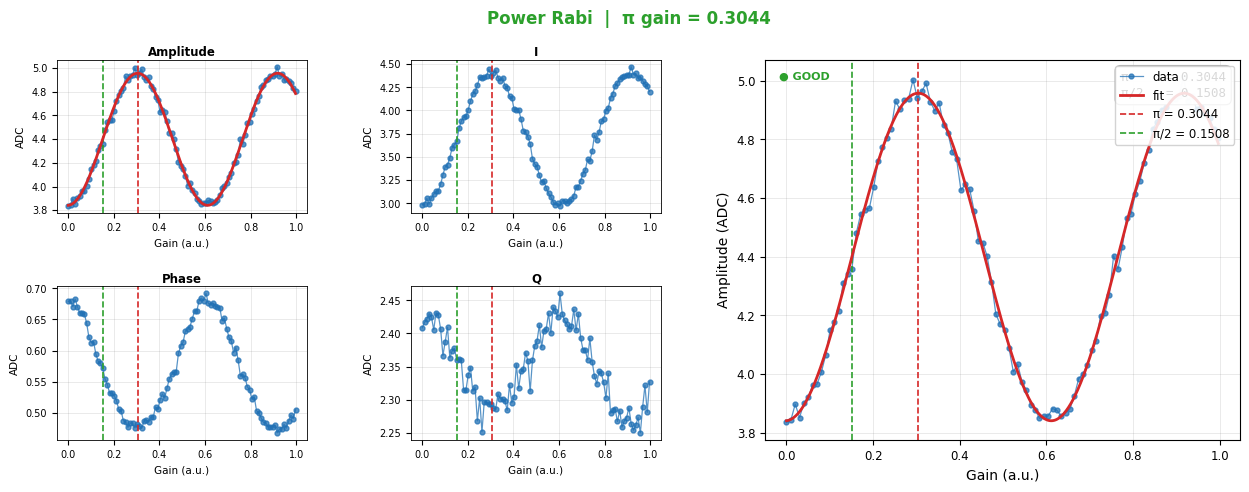

In [33]:
from QickworkspaceV2.experiments.qubit_ef import PowerRabiEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabiEf(run_cfg)
result_ef = prabi_ef.run(50)
pi_gain_ef = result_ef["pi_gain"]
pi2_gain_ef = result_ef["pi2_gain"]
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
# prabi_ef.saveLabber(qubit, config_all=config_all)

## Qubit Temperature ef

[Temp] A_meas=0.0332  A_ref=0.5757  ratio=0.0577
[Temp] Estimated temperature: 61.04 mK
[Temp] Temperature error: +/- 5.98 mK
[Temp] 1-sigma temperature floor: 42.18 mK


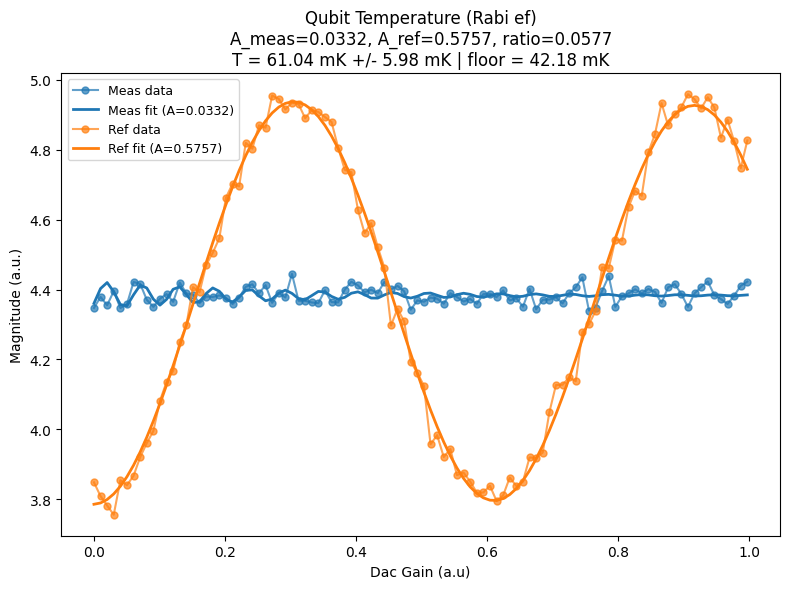

ExperimentData(type='s013b_qubit_temp_ef', id='672b7ce1', quality=good, status=complete)

In [36]:
from QickworkspaceV2.experiments.qubit_ef import QubitTemp

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),

    ]
)

rabi_temp = QubitTemp(run_cfg)
rabi_temp.run(5)
# rabi_temp.saveLabber(qubit, config_all=config_all)

## Ramsey ef

Experiment interrupted at 3 averages. Fit is based on partial data.


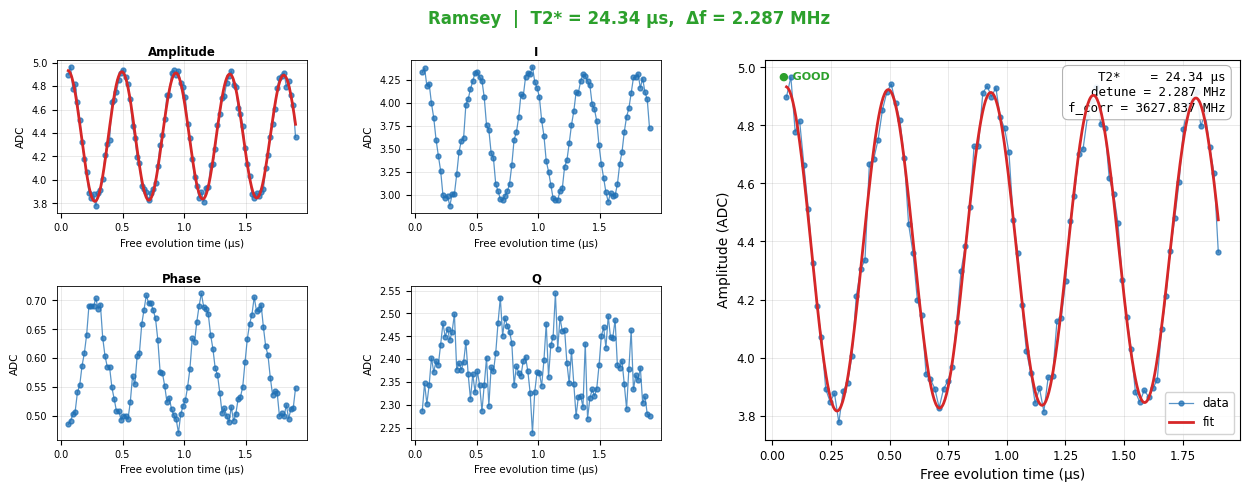

ExperimentData(type='s012_Ramsey_ef', id='eb49a6d7', quality=good, status=interrupted)

In [34]:
from QickworkspaceV2.experiments.qubit_ef import RamseyEf

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),
    ]
)

t2r_ef = RamseyEf(run_cfg)
t2r_ef.run(100)
# t2r_ef.saveLabber(qubit, config_all=config_all)

In [35]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune 0.28727MHz


## T1 ef

Experiment interrupted at 13 averages. Fit is based on partial data.


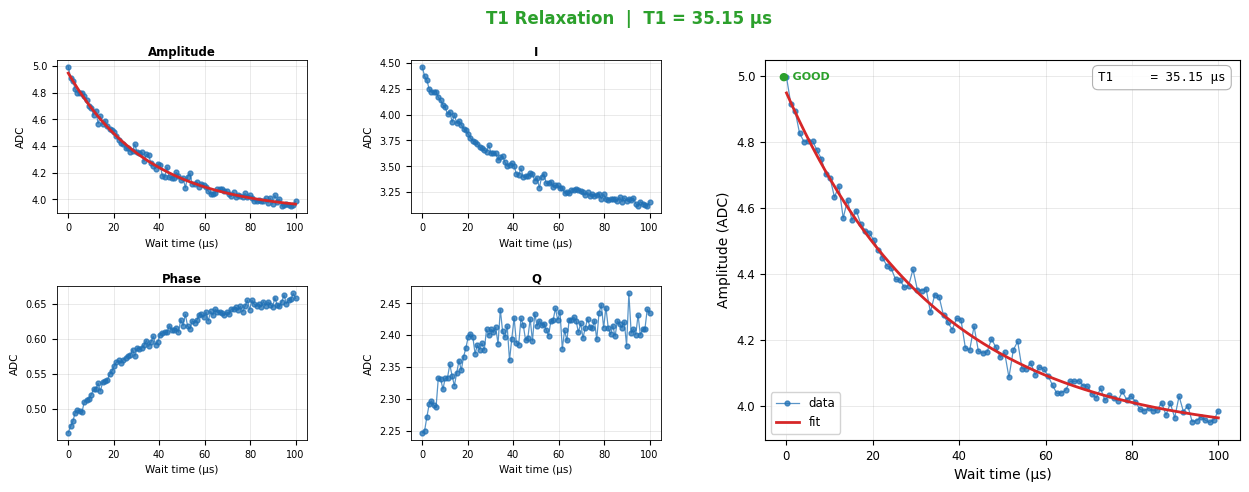

ExperimentData(type='s013_T1_ef', id='eee74ad5', quality=good, status=interrupted)

In [37]:
from QickworkspaceV2.experiments.qubit_ef import T1Ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
    ]
)

t1_ef = T1Ef(run_cfg)
t1_ef.run(50)
# t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef (ef)

  0%|          | 0/5000 [00:00<?, ?it/s]

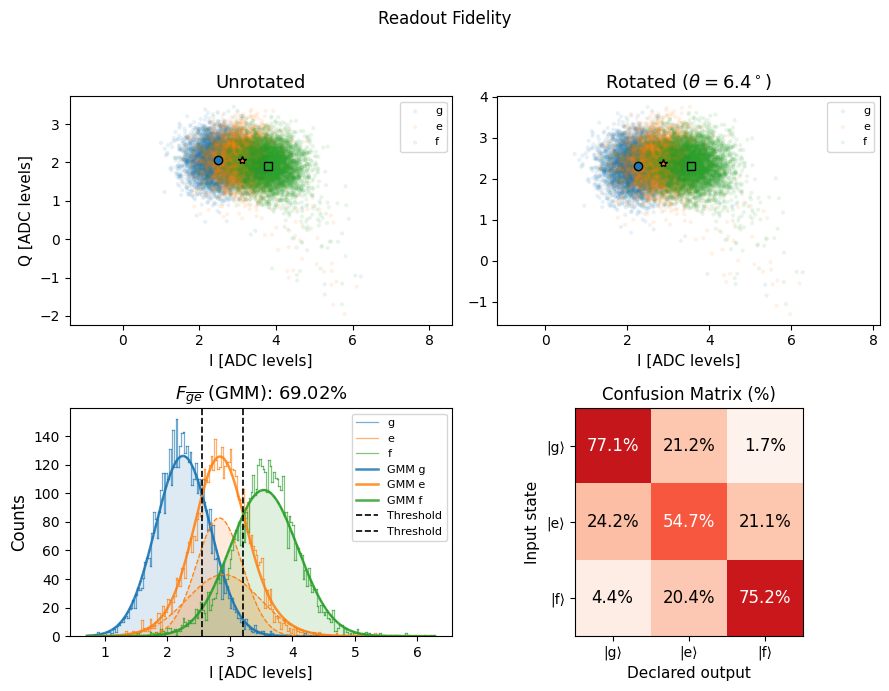

Rotation angle : 6.36 deg
GMM Fidelity   : 69.020%
  |g⟩  components=1  primary_mean=2.250  primary_std=0.440  secondary_weight=0.000
  |e⟩  components=2  primary_mean=2.831  primary_std=0.368  secondary_weight=0.452  ⚠ secondary component large
  |f⟩  components=1  primary_mean=3.543  primary_std=0.543  secondary_weight=0.000
Thresholds     : ['2.555', '3.212']
Confusion Matrix (%):
 [[77.1 21.2  1.7]
 [24.2 54.7 21.1]
 [ 4.4 20.4 75.2]]


[[0.6901999999999999],
 [2.554953165031545, 3.212053477026582],
 6.364569949247289,
 array([[77.1 , 21.16,  1.74],
        [24.16, 54.74, 21.1 ],
        [ 4.36, 20.42, 75.22]])]

In [42]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = 'drag'

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

### ssh opt (ef)

In [ ]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt

USE_DRAG = True

run_cfg = config_all.get_qubit(qubit)
if USE_DRAG:
    run_cfg["pulse_type"] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 5, 4)
gain_axis = np.linspace(0.05, 0.1, 3)
length_axis = np.linspace(1, 4, 4)
sweep_para = {"freq": freq_axis, "gain": gain_axis, "length": length_axis}

SHOT = 1000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para, shot_f=True)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

if USE_DRAG:
    run_cfg["pulse_type"] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

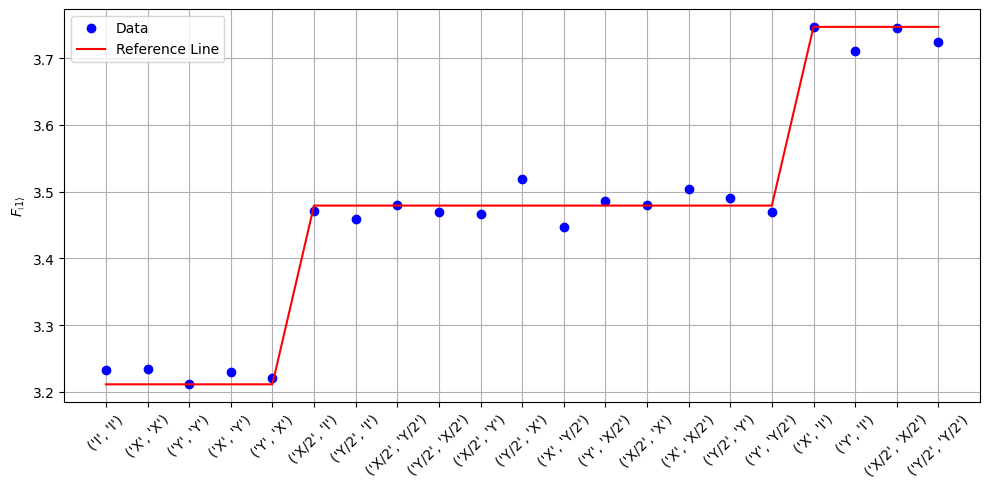

In [43]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

### Drag AllXY

In [ ]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("pulse_type", "drag"),
    ]
)
allxy = AllXY(run_cfg)
allxy.run(10, iq_process="real")
allxy.plot()

## State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (2.4775415512465373+2.0517873961218838j), IQ Excited: (3.110812326869806+2.0510574792243768j)


Tomography (x180):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.2169, <Y>=-0.0290, <Z>=-1.0000
Purity: 1.00000


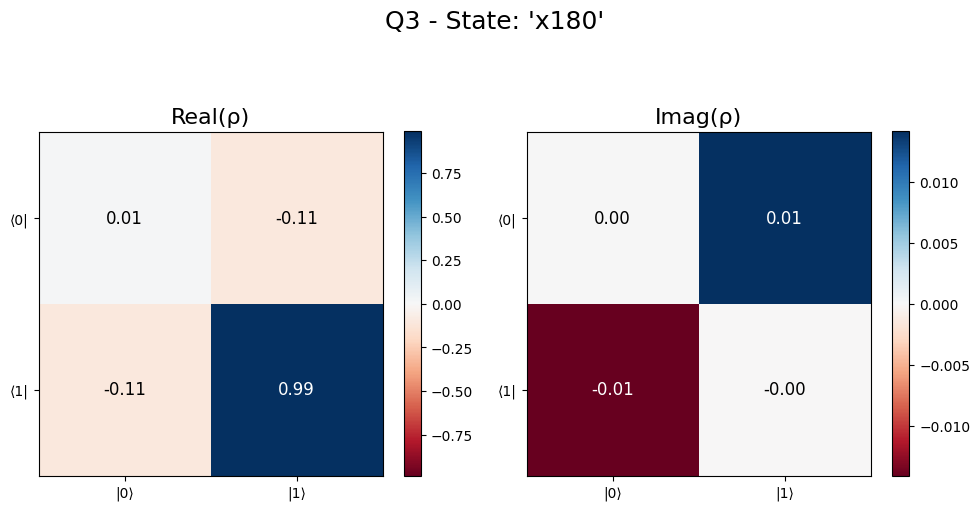

c:\Users\cluster\Desktop\QickworksaceV2_proj\QickworkspaceV2\experiments\characterization\state_tomography.py:217: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


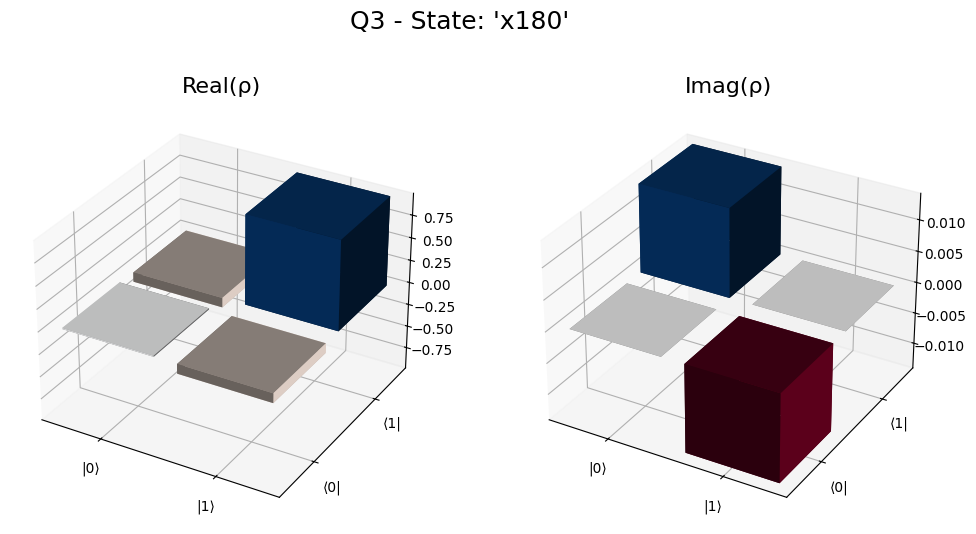

(<Figure size 1200x600 with 2 Axes>, None)

In [44]:
from QickworkspaceV2.experiments.characterization import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(run_cfg)
tomo.run(py_avg=pyavg, prep_pulse_name="x180")
tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

In [ ]:
from QickworkspaceV2.experiments.characterization import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg["pulse_type"] = "drag"

auto = AutoRB(run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=5,
    max_circuit_depth=600,
    delta_clifford=50,
    number_sample=50,
    interleaved_gates=interleaved,
    iq_process="real",
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())

In [ ]:
from QickworkspaceV2.experiments.characterization import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)

# Drag

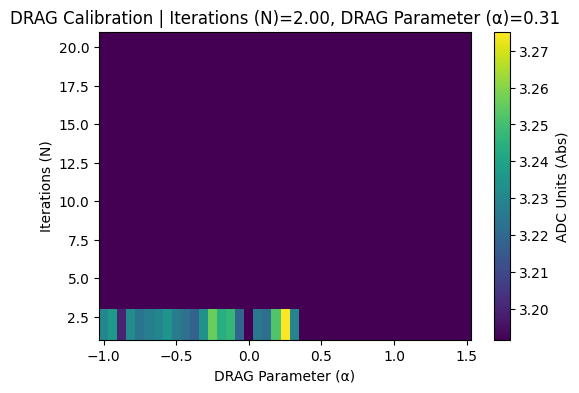

Outer Sweep: Iterations (N):   0%|          | 0/10 [00:00<?, ?it/s]

Inner Sweep: DRAG Parameter (α):   0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start", -1),
        ("alpha_stop", 1.5),
        ("alpha_steps", 41),
        # Iterations
        ("iteration_start", 2),
        ("iteration_stop", 20),
        ("iteration_step", 2),
    ]
)

drag_cal = DragCalibration(run_cfg)
fit_results = drag_cal.run(py_avg=5)

config_all.update("drag_alpha", fit_results["optimal_alpha"], q_index=qubit)
# drag_cal.saveLabber(qubit, config_all=config_all)